# Understanding Convolutional Neural Network and it´s Implementation for Classification Problem


In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# (x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Reshape dataset to match model´s expected input shape (28,28,3)
x_train = x_train.reshape(-1, 32, 32, 3).astype("float32") / 255.0
x_test = x_test.reshape(-1, 32, 32, 3).astype("float32") / 255.0

In [8]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [9]:
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.4832 - loss: 1.4364 - val_accuracy: 0.5893 - val_loss: 1.1788
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6142 - loss: 1.0968 - val_accuracy: 0.6485 - val_loss: 1.0176
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6653 - loss: 0.9608 - val_accuracy: 0.6660 - val_loss: 0.9617
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6960 - loss: 0.8740 - val_accuracy: 0.6810 - val_loss: 0.9267
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7211 - loss: 0.8062 - val_accuracy: 0.6899 - val_loss: 0.8993
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7408 - loss: 0.7487 - val_accuracy: 0.6839 - val_loss: 0.9396
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7568 - loss: 0.6998 - val_accuracy: 0.6994 - val_loss: 0.8970
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7709 - loss: 0

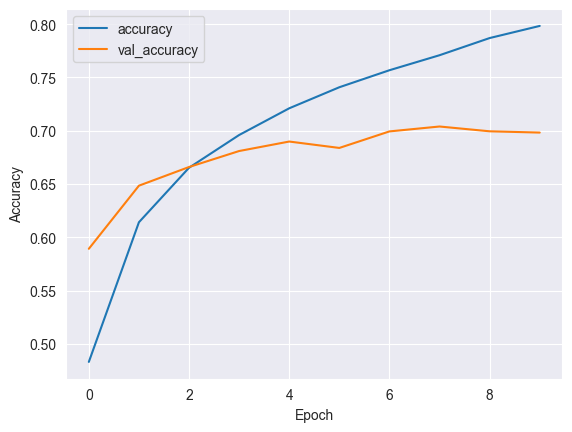

In [10]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


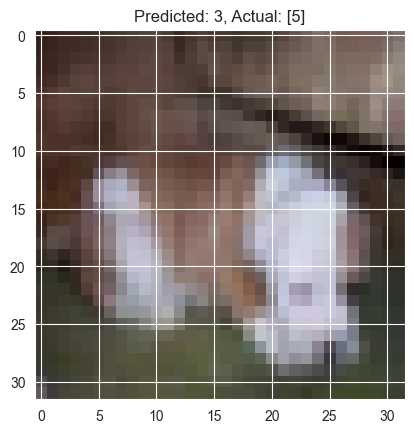

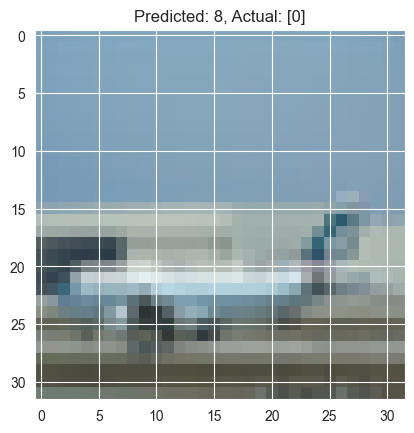

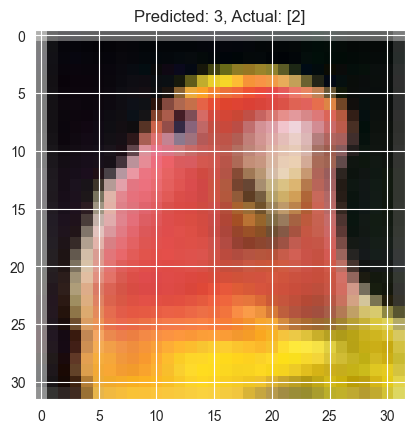

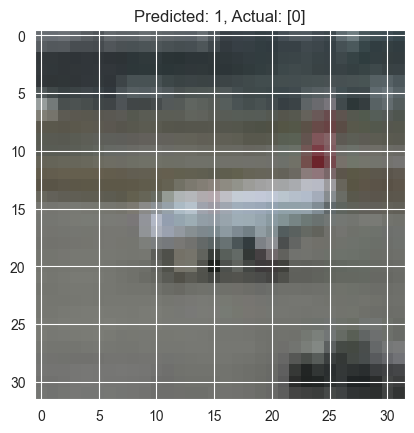

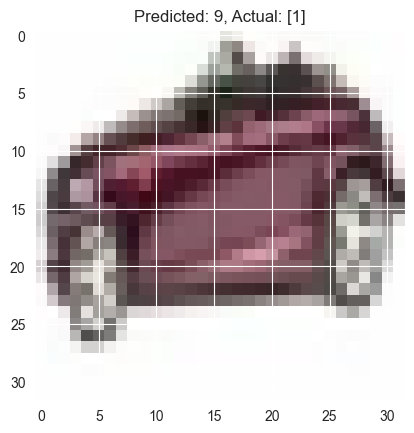

In [14]:
import random
predictions = model.predict(x_test)
misclassified_indices = [i for i in range(len(y_test)) if np.argmax(predictions[i]) != y_test[i]]
random_samples = random.sample(misclassified_indices, 5)

for i in random_samples:
  plt.imshow(x_test[i])
  plt.title(f"Predicted: {np.argmax(predictions[i])}, Actual: {y_test[i]}")
  plt.show()

In [24]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

def load_and_predict(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)

    if image is None:
        print("Error: Image not loaded. Check file path.")
    else:
        # Display the original and processed images
        plt.figure(figsize=(10, 5))

        # Original Image
        plt.subplot(1, 2, 1)
        plt.imshow(image)
        plt.title("Original Image")
        plt.axis('off')

        # 2. Convert BGR to RGB (so the colors look right)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # 3. Resize to 32x32
        image_resized = cv2.resize(image_rgb, (32, 32))

        # 4. Normalize
        image_normalized = image_resized.astype("float32") / 255.0

        # 5. Expand dimensions to (1, 32, 32, 3) for the model
        # Use np.expand_dims instead of reshape for cleaner code
        input_tensor = np.expand_dims(image_normalized, axis=0)

        prediction = model.predict(input_tensor)
        predicted_label = np.argmax(prediction)

        predicted_name = class_names[predicted_label]

        # Display
        plt.subplot(1, 2, 2)
        plt.imshow(image_resized)
        plt.title(f"Predicted Class: {predicted_name}")
        plt.axis('off')
        plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


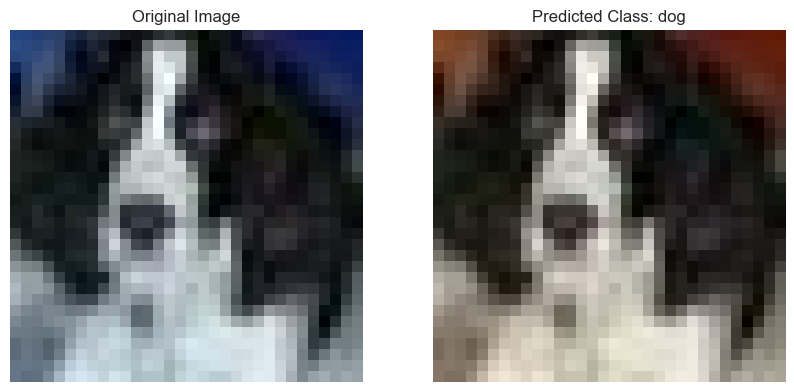

In [25]:
load_and_predict("./Test_CIFAR/0021.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


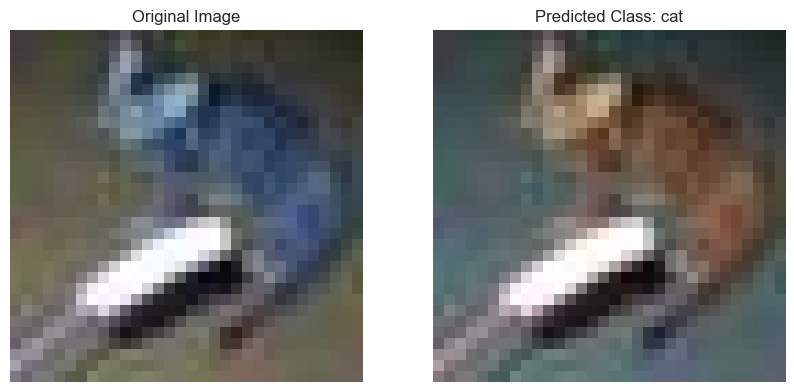

In [26]:
load_and_predict("./Test_CIFAR/0011.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


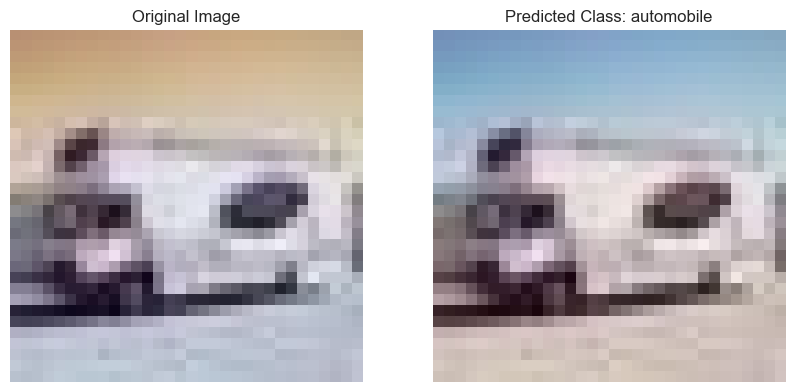

In [27]:
load_and_predict("./Test_CIFAR/0043.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


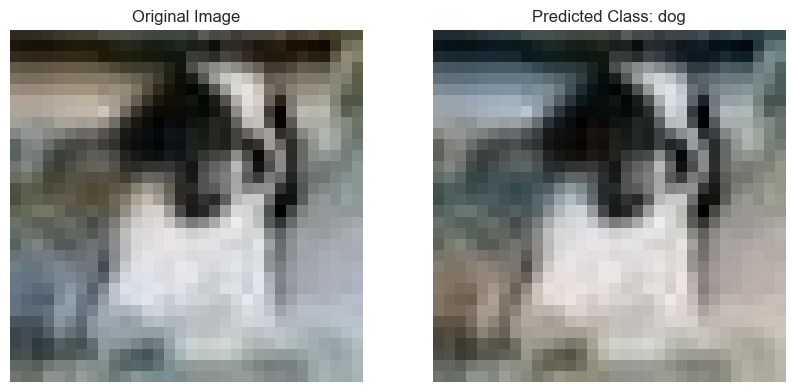

In [28]:
load_and_predict("./Test_CIFAR/0050.jpg")